In [4]:
import os
import glob
import json
import random
import datetime
import re
import cv2
import math
from typing import List, Optional, Dict, Any, Tuple
from copy import deepcopy

import numpy as np
from pathlib import Path

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader, IterableDataset, TensorDataset
from torchvision import transforms

import matplotlib.pyplot as plt
from PIL import Image

from scipy.stats import ttest_ind

from captum.concept import TCAV, Concept, Classifier
from captum.attr import LayerGradientXActivation, LayerIntegratedGradients
from captum.concept._utils.data_iterator import dataset_to_dataloader, CustomIterableDataset
from captum.concept._utils.common import concepts_to_str


from model.model import Net
from tools import utils, plotting, metrics, model_io, tcav, data


In [5]:
DEVICE = torch.device("cpu")

CKPT  = Path("weights/aixi_shape_ssin.pt")

In [6]:
def transform(img):
    return transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Grayscale(),
            transforms.Resize((128, 128), antialias=True)
        ]
    )(img)

def get_tensor_from_filename(filename):
    img = Image.open(filename).convert("L")
    return transform(img).to(DEVICE).float()


def load_image_tensors(class_name, root_path='data/concepts', transform=True):
    path = os.path.join(root_path, class_name)

    patterns = ('*.png', '*.jpg', '*.jpeg', '*.bmp')
    filenames = []
    for pat in patterns:
        filenames.extend(glob.glob(os.path.join(path, pat)))

    if not filenames:
        print(f"[load_image_tensors] no files under: {os.path.abspath(path)}")

    images = []
    for filename in sorted(filenames):
        img = Image.open(filename).convert("L")
        images.append(transform(img) if callable(transform) else img)
    return images

def assemble_concept(name, id, concepts_path="data/concepts"):
    concept_path = os.path.join(concepts_path, name) + "/"
    dataset = CustomIterableDataset(get_tensor_from_filename, concept_path)
    concept_iter = dataset_to_dataloader(dataset)

    return Concept(id=id, name=name, data_iter=concept_iter)

def load_image_tensors(class_name, root_path='/Users/dylancanning/Desktop/Tcav_Captum/Testing-with-Concept-Activation-Vectors/data/aixi_shape/', transform_bool=True):
    path = os.path.join(root_path, class_name)
    
    filenames = glob.glob(path + '/*.png')
    
        

    tensors = []
    for filename in filenames:
        img = Image.open(filename).convert("L")
        tensors.append(transform(img) if transform_bool else img)
        
    
    return tensors

In [7]:

def format_float(f):
    return float('{:.3f}'.format(f) if abs(f) >= 0.0005 else '{:.3e}'.format(f))

def plot_tcav_scores(experimental_sets, tcav_scores, layers):
    fig, ax = plt.subplots(1, len(experimental_sets), figsize = (25, 7))

    barWidth = 1 / (len(experimental_sets[0]) + 1)

    for idx_es, concepts in enumerate(experimental_sets):

        concepts = experimental_sets[idx_es]
        concepts_key = concepts_to_str(concepts)

        pos = [np.arange(len(layers))]
        for i in range(1, len(concepts)):
            pos.append([(x + barWidth) for x in pos[i-1]])
        _ax = (ax[idx_es] if len(experimental_sets) > 1 else ax)
        for i in range(len(concepts)):
            val = [format_float(scores['sign_count'][i]) for layer, scores in tcav_scores[concepts_key].items()]
            _ax.bar(pos[i], val, width=barWidth, edgecolor='white', label=concepts[i].name)

        
        _ax.set_xlabel('Set {}'.format(str(idx_es)), fontweight='bold', fontsize=16)
        _ax.set_xticks([r + 0.3 * barWidth for r in range(len(layers))])
        _ax.set_xticklabels(layers, fontsize=16)

        
        _ax.legend(fontsize=16)

    plt.show()

def plot_tcav_scores_vertical(experimental_sets, tcav_scores, layer_names=None):
    import numpy as np
    import matplotlib.pyplot as plt

    layers = layer_names or LAYER_NAMES
    n_sets = len(experimental_sets)

    
    fig, axes = plt.subplots(n_sets, 1, figsize=(25, 6 * n_sets), constrained_layout=True)
    if n_sets == 1:
        axes = [axes]  

    
    for idx_es, concepts in enumerate(experimental_sets):
        ax = axes[idx_es]

        
        x = np.arange(len(layers))
        n_concepts = len(concepts)
        bar_width = 0.8 / n_concepts

        
        offsets = (np.arange(n_concepts) - (n_concepts - 1) / 2.0) * bar_width

        concepts_key = concepts_to_str(concepts)  

        for i in range(n_concepts):
            
            vals = [format_float(tcav_scores[concepts_key][layer]['sign_count'][i])
                    for layer in layers]
            ax.bar(x + offsets[i], vals, width=bar_width, edgecolor='white',
                   label=concepts[i].name)

        ax.set_title(f"Set {idx_es}", fontweight='bold', fontsize=16)
        ax.set_xticks(x)
        ax.set_xticklabels(layers, fontsize=12, rotation=0)
        ax.set_ylabel('TCAV sign count', fontsize=12)
        ax.legend(fontsize=12)
        ax.grid(axis='y', linestyle=':', alpha=0.4)

    plt.show()
    
def plot_tcav_directional(experimental_sets, tcav_scores, layer_names=None, show_sign_dots=True):
    """
    Plots signed TCAV 'magnitude' for each concept at each layer.
    Positive bar: increases the target logit. Negative: decreases it.
    Optionally overlays a dot based on majority sign from 'sign_count'.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    
    def present_layers_for_key(ck, preferred):
        return [ly for ly in (preferred or []) if ly in tcav_scores[ck]]

    n_sets = len(experimental_sets)
    fig, axes = plt.subplots(n_sets, 1, figsize=(24, 5 * n_sets), constrained_layout=True)
    if n_sets == 1:
        axes = [axes]

    for idx_es, concepts in enumerate(experimental_sets):
        ck = concepts_to_str(concepts)
        
        preferred = layer_names if layer_names else list(tcav_scores[ck].keys())
        layers = present_layers_for_key(ck, preferred) or list(tcav_scores[ck].keys())

        ax = axes[idx_es]
        x = np.arange(len(layers))
        n_concepts = len(concepts)
        bar_w = 0.8 / max(1, n_concepts)
        offsets = (np.arange(n_concepts) - (n_concepts - 1) / 2.0) * bar_w

        
        for i in range(n_concepts):
            vals = [ format_float(tcav_scores[ck][ly]['magnitude'][i]) for ly in layers ]
            ax.bar(x + offsets[i], vals, width=bar_w, edgecolor='white', label=concepts[i].name)

            if show_sign_dots and 'sign_count' in tcav_scores[ck][layers[0]]:
                
                sc = [ format_float(tcav_scores[ck][ly]['sign_count'][i]) for ly in layers ]
                
                
                dots_y = []
                for ly_idx, ly in enumerate(layers):
                    sc_i = format_float(tcav_scores[ck][ly]['sign_count'][i])
                    
                    try:
                        max_sc_layer = max(format_float(tcav_scores[ck][ly]['sign_count'][j]) for j in range(n_concepts))
                    except Exception:
                        max_sc_layer = 1.0
                    
                    majority_up = sc_i > (max_sc_layer / 2.0)
                    
                    dots_y.append(0.02 if majority_up else -0.02)
                ax.scatter(x + offsets[i], dots_y, s=30, marker='o')

        ax.axhline(0.0, color='k', linewidth=1)
        ax.set_title(f"Set {idx_es}: " + ", ".join([c.name for c in concepts]), fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(layers, rotation=0, fontsize=12)
        ax.set_ylabel("Signed TCAV magnitude", fontsize=12)
        ax.grid(axis='y', linestyle=':', alpha=0.35)
        ax.legend(fontsize=11)

    plt.show()



In [8]:
concepts_path = "./data/concepts"

circle_full        = assemble_concept("circle_full", 0, concepts_path=concepts_path)
circle_half_bottom = assemble_concept("circle_half_bottom", 1, concepts_path=concepts_path)
circle_half_left   = assemble_concept("circle_half_left", 2, concepts_path=concepts_path)
circle_half_right  = assemble_concept("circle_half_right", 3, concepts_path=concepts_path)
circle_half_top    = assemble_concept("circle_half_top", 4, concepts_path=concepts_path)

circle_quarter_bl  = assemble_concept("circle_quarter_bl", 5, concepts_path=concepts_path)
circle_quarter_br  = assemble_concept("circle_quarter_br", 6, concepts_path=concepts_path)
circle_quarter_tl  = assemble_concept("circle_quarter_tl", 7, concepts_path=concepts_path)
circle_quarter_tr  = assemble_concept("circle_quarter_tr", 8, concepts_path=concepts_path)

cross_arm_bottom   = assemble_concept("cross_arm_bottom", 9, concepts_path=concepts_path)
cross_arm_left     = assemble_concept("cross_arm_left", 10, concepts_path=concepts_path)
cross_arm_right    = assemble_concept("cross_arm_right", 11, concepts_path=concepts_path)
cross_arm_top      = assemble_concept("cross_arm_top", 12, concepts_path=concepts_path)
cross_arm_horizontal = assemble_concept("cross_arm_horizontal", 13, concepts_path=concepts_path)
cross_arm_vertical   = assemble_concept("cross_arm_vertical", 14, concepts_path=concepts_path)
cross_full         = assemble_concept("cross_full", 15, concepts_path=concepts_path)

random_pool        = assemble_concept("random_pool", 16, concepts_path=concepts_path)
random_pool_2        = assemble_concept("random_pool_2", 17, concepts_path=concepts_path)

square_corner_bl   = assemble_concept("square_corner_bl", 18, concepts_path=concepts_path)
square_corner_br   = assemble_concept("square_corner_br", 19, concepts_path=concepts_path)
square_corner_tl   = assemble_concept("square_corner_tl", 20, concepts_path=concepts_path)
square_corner_tr   = assemble_concept("square_corner_tr", 21, concepts_path=concepts_path)

square_edge_bottom = assemble_concept("square_edge_bottom", 22, concepts_path=concepts_path)
square_edge_left   = assemble_concept("square_edge_left", 23, concepts_path=concepts_path)
square_edge_right  = assemble_concept("square_edge_right", 24, concepts_path=concepts_path)
square_edge_top    = assemble_concept("square_edge_top", 25, concepts_path=concepts_path)

square_full        = assemble_concept("square_full", 26, concepts_path=concepts_path)
square_half_bottom = assemble_concept("square_half_bottom", 27, concepts_path=concepts_path)
square_half_left   = assemble_concept("square_half_left", 28, concepts_path=concepts_path)
square_half_right  = assemble_concept("square_half_right", 29, concepts_path=concepts_path)
square_half_top    = assemble_concept("square_half_top", 30, concepts_path=concepts_path)

random_pool_3        = assemble_concept("random_pool_3", 31, concepts_path=concepts_path)
random_pool_4        = assemble_concept("random_pool_4", 32, concepts_path=concepts_path)

ALL_CONCEPTS = [
    circle_full,
    circle_half_bottom, circle_half_left, circle_half_right, circle_half_top,
    circle_quarter_bl, circle_quarter_br, circle_quarter_tl, circle_quarter_tr,
    cross_arm_bottom, cross_arm_left, cross_arm_right, cross_arm_top,
    cross_arm_horizontal, cross_arm_vertical, cross_full,
    square_corner_bl, square_corner_br, square_corner_tl, square_corner_tr,
    square_edge_bottom, square_edge_left, square_edge_right, square_edge_top,
    square_full, square_half_bottom, square_half_left, square_half_right, square_half_top,
]

RANDOM_POOL = [random_pool, random_pool_2]

In [9]:
sets_circle = [
    [circle_full, random_pool],
    [circle_full, random_pool_2],
    [circle_full, random_pool_3],
    [circle_full, random_pool_4]
]

sets_square = [
    [square_full, random_pool],
    [square_full, random_pool_2],
    [square_full, random_pool_3],
    [square_full, random_pool_4]
]

sets_cross = [
    [cross_full, random_pool],
    [cross_full, random_pool_2],
    [cross_full, random_pool_3],
    [cross_full, random_pool_4]
]

In [10]:
LAYERS = ["relu3", "relu4", "relu5", "relu6", "relu7", "relu8", "fc3", "fc4"]

In [11]:
x_clean  = transform(Image.open("data/aixi_shape/val/00285.png").convert("L")).unsqueeze(0).to(DEVICE)
x_square = transform(Image.open("data/aixi_shape/val/00353.png").convert("L")).unsqueeze(0).to(DEVICE)
x_cross  = transform(Image.open("data/aixi_shape/val/00446.png").convert("L")).unsqueeze(0).to(DEVICE)
x_circle = transform(Image.open("data/aixi_shape/val/00332.png").convert("L")).unsqueeze(0).to(DEVICE)
x_mixed  = transform(Image.open("data/aixi_shape/val/00389.png").convert("L")).unsqueeze(0).to(DEVICE)
x_mixed_2= transform(Image.open("data/aixi_shape/val/00448.png").convert("L")).unsqueeze(0).to(DEVICE)
x_mixed_3= transform(Image.open("data/aixi_shape/val/00396.png").convert("L")).unsqueeze(0).to(DEVICE)

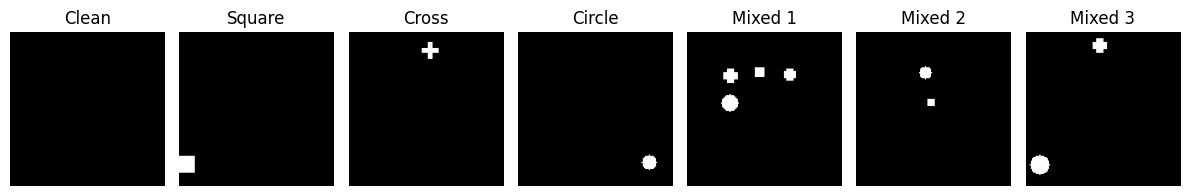

In [12]:
imgs = {
    "Clean":  x_clean,
    "Square": x_square,
    "Cross":  x_cross,
    "Circle": x_circle,
    "Mixed 1": x_mixed,
    "Mixed 2": x_mixed_2,
    "Mixed 3": x_mixed_3
}

fig, axes = plt.subplots(1, len(imgs), figsize=(12, 4))

for ax, (title, tensor) in zip(axes, imgs.items()):
    img = tensor.squeeze().cpu().numpy()   
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [13]:
def _load_state_dict(ckpt_path: Path) -> dict:
    obj = torch.load(ckpt_path, map_location="mps")
    if isinstance(obj, dict) and ("state_dict" in obj or "model_state_dict" in obj):
        sd = obj.get("state_dict", obj.get("model_state_dict"))
    else:
        sd = obj
    sd = { (k[7:] if k.startswith("module.") else k): v for k, v in sd.items() }
    return sd

sd = _load_state_dict(CKPT)

in_channels = sd["conv1.weight"].shape[1]                 
num_classes = sd["fc4.weight"].shape[0]               
model = Net(numChannels=in_channels, classes=num_classes, size_img=128)
model.load_state_dict(sd, strict=True)
model.to(DEVICE).eval()

print(f"Loaded Net(in_channels={in_channels}, classes={num_classes}) on {DEVICE}")


Loaded Net(in_channels=1, classes=1) on cpu


In [14]:
def flip_only_first_concept(tcav_scores, experimental_sets, anchor_layer="fc4"):
    """
    For each set [concept, random_k], if the concept's magnitude at anchor_layer is negative,
    flip its sign across all layers. For local runs (1 image), also flip 0/1 sign_count.
    """
    fixed = deepcopy(tcav_scores)
    for concepts in experimental_sets:
        ck = concepts_to_str(concepts)
        layers_here = list(fixed[ck].keys())
        anchor = anchor_layer if anchor_layer in fixed[ck] else layers_here[-1]
        m0 = float(fixed[ck][anchor]['magnitude'][0])
        if m0 < 0:
            for ly in fixed[ck]:
                fixed[ck][ly]['magnitude'][0] = -fixed[ck][ly]['magnitude'][0]
                if 'sign_count' in fixed[ck][ly]:
                    sc = float(fixed[ck][ly]['sign_count'][0])
                    if sc in (0.0, 1.0):
                        fixed[ck][ly]['sign_count'][0] = 1.0 - sc
    return fixed

def aggregate_concept_across_random_pools(tcav_scores, experimental_sets, layers, concept_index=0):
    """
    experimental_sets looks like [[concept, random_k], ...].
    Returns {layer: (mean, std)} for the concept (index 0) across pools.
    """
    per_layer = {ly: [] for ly in layers}
    for concepts in experimental_sets:
        ck = concepts_to_str(concepts)
        for ly in layers:
            per_layer[ly].append(float(tcav_scores[ck][ly]['magnitude'][concept_index]))
    return {ly: (float(np.mean(v)), float(np.std(v))) for ly, v in per_layer.items()}

def print_agg_table(title, agg_dict, layers):
    print(f"\n=== {title} ===")
    for ly in layers:
        mu, sd = agg_dict[ly]
        print(f"{ly:>5s}: {mu:+.3f} ± {sd:.3f}")


def plot_concept_group(experimental_sets, tcav_scores, layers):
    import matplotlib.pyplot as plt
    n_sets = len(experimental_sets)
    fig, ax = plt.subplots(1, n_sets, figsize=(5*n_sets, 4))
    if n_sets == 1: ax = [ax]
    for i, concepts in enumerate(experimental_sets):
        ck = concepts_to_str(concepts)
        vals0 = [float(tcav_scores[ck][ly]['magnitude'][0]) for ly in layers]  
        vals1 = [float(tcav_scores[ck][ly]['magnitude'][1]) for ly in layers]  
        x = np.arange(len(layers))
        ax[i].bar(x - 0.17, vals0, width=0.33, label=concepts[0].name)
        ax[i].bar(x + 0.17, vals1, width=0.33, label=concepts[1].name)
        ax[i].axhline(0, color='k', lw=1)
        ax[i].set_title(concepts_to_str(concepts))
        ax[i].set_xticks(x)
        ax[i].set_xticklabels(layers, rotation=0)
        ax[i].legend()
    plt.tight_layout(); plt.show()


tcav_obj = TCAV(
    model=model,
    layers=LAYERS,                     
    attribute_to_layer_input=True,     
    
    model_id="exp_tcav_all",
    save_path="./cav"
)



all_sets = sets_circle + sets_cross + sets_square
tcav_obj.compute_cavs(all_sets, force_train=True)


def run_tcav_for_image(x, sets, label):
    """
    x: (1,1,H,W) tensor on DEVICE
    sets: [[concept, random_k], ...] for a single concept family
    label: string tag for printing
    """
    
    raw = tcav_obj.interpret(inputs=x, experimental_sets=sets, target=0)

    flipped = flip_only_first_concept(raw, sets, anchor_layer="fc4")

    agg = aggregate_concept_across_random_pools(flipped, sets, LAYERS, concept_index=0)

    late = [ly for ly in LAYERS if ly in ("relu8","fc3","fc4")]
    early = [ly for ly in LAYERS if ly not in late]
    print_agg_table(f"{label} — concept={sets[0][0].name}", {**{k:agg[k] for k in late}, **{k:agg[k] for k in early}}, late+early)

    return agg, flipped




for name, x in imgs.items():
    print(f"\n######## IMAGE: {name} ########")
    agg_circle, _ = run_tcav_for_image(x, sets_circle, label=f"{name}")
    agg_cross,  _ = run_tcav_for_image(x, sets_cross,  label=f"{name}")
    agg_square, _ = run_tcav_for_image(x, sets_square, label=f"{name}")

    
    def f(d, key): 
        mu, sd = d[key]
        return f"{mu:+.3f}±{sd:.3f}"
    print(f"\n[{name}] fc4 summary → circle {f(agg_circle,'fc4')} | cross {f(agg_cross,'fc4')} | square {f(agg_square,'fc4')}")


/opt/miniconda3/lib/python3.12/site-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()


KeyboardInterrupt: 

In [19]:
ALL_SETS = sets_circle + sets_cross + sets_square

my_empty_tcav = TCAV(
    model=model,
    layers=LAYERS,
    layer_attr_method=LayerIntegratedGradients(model, None, multiply_by_inputs=False),
    attribute_to_layer_input=True,
)

results_empty = my_empty_tcav.interpret(
    inputs=x_clean, 
    experimental_sets=ALL_SETS, 
    target=0,
    n_steps=16,              
    internal_batch_size=1,
)


/opt/miniconda3/lib/python3.12/site-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()


In [20]:
results_empty

defaultdict(<function captum.concept._core.tcav.TCAV.interpret.<locals>.<lambda>()>,
            {'0-16': defaultdict(None,
                         {'relu3': {'sign_count': tensor([0., 1.]),
                           'magnitude': tensor([-0.0007,  0.0007])},
                          'relu4': {'sign_count': tensor([1., 0.]),
                           'magnitude': tensor([ 7.1921e-05, -7.1921e-05])},
                          'relu5': {'sign_count': tensor([1., 0.]),
                           'magnitude': tensor([ 0.0007, -0.0007])},
                          'relu6': {'sign_count': tensor([1., 0.]),
                           'magnitude': tensor([ 8.3930e-05, -8.3930e-05])},
                          'relu7': {'sign_count': tensor([0., 1.]),
                           'magnitude': tensor([-0.0003,  0.0003])},
                          'relu8': {'sign_count': tensor([1., 0.]),
                           'magnitude': tensor([ 0.1111, -0.1111])},
                          'fc3': {'sig

In [24]:
def format_float(f):
    return float('{:.3f}'.format(f) if abs(f) >= 0.0005 else '{:.3e}'.format(f))

def plot_tcav_scores(experimental_sets, tcav_scores, layers):
    n_sets = len(experimental_sets)
    fig, axes = plt.subplots(n_sets, 1, figsize=(15, 5 * n_sets), constrained_layout=True)

    if n_sets == 1:
        axes = [axes]

    barWidth = 1 / (len(experimental_sets[0]) + 1)

    for idx_es, concepts in enumerate(experimental_sets):
        concepts_key = concepts_to_str(concepts)
        ax = axes[idx_es]

        pos = [np.arange(len(layers))]
        for i in range(1, len(concepts)):
            pos.append([x + barWidth for x in pos[i - 1]])

        for i in range(len(concepts)):
            vals = [format_float(scores['sign_count'][i]) 
                    for layer, scores in tcav_scores[concepts_key].items()]
            ax.bar(pos[i], vals, width=barWidth, edgecolor='white', label=concepts[i].name)

        ax.set_title(f"Set {idx_es}: " + ", ".join([c.name for c in concepts]), fontsize=14, fontweight='bold')
        ax.set_xticks([r + 0.3 * barWidth for r in range(len(layers))])
        ax.set_xticklabels(layers, fontsize=12, rotation=30)
        ax.set_ylabel("TCAV score")
        ax.legend(fontsize=12)
        ax.grid(axis='y', linestyle=':', alpha=0.4)

    plt.show()


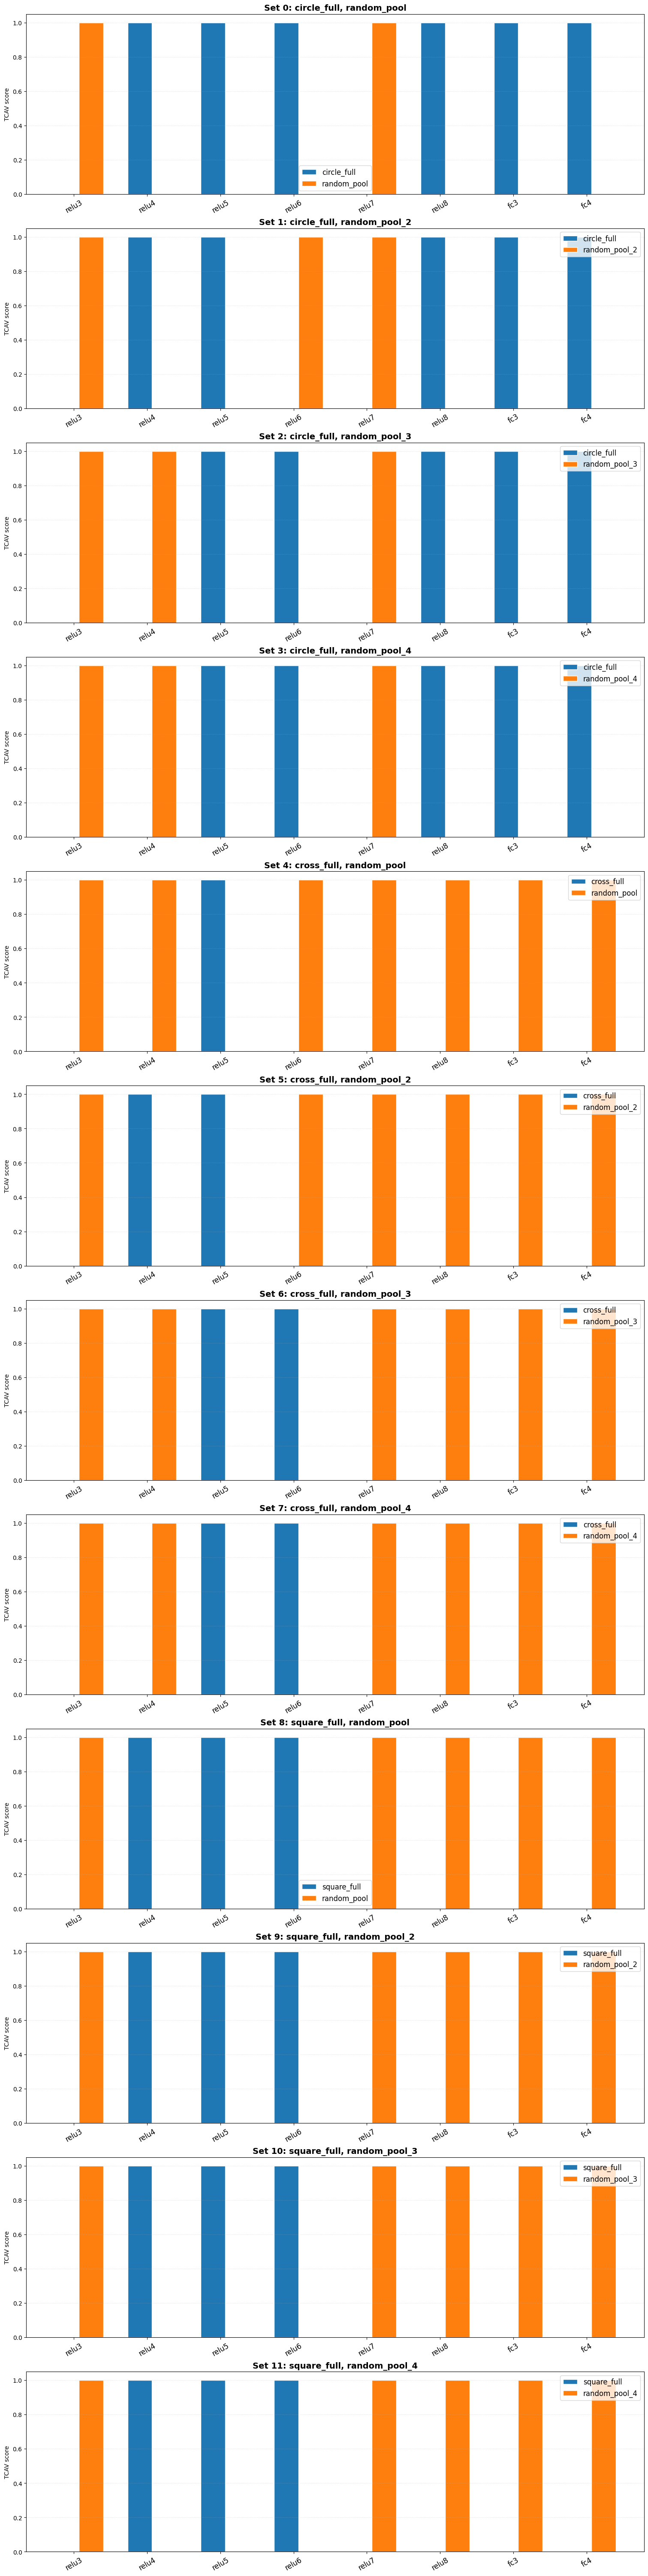

In [25]:
plot_tcav_scores(ALL_SETS, results_empty, LAYERS)

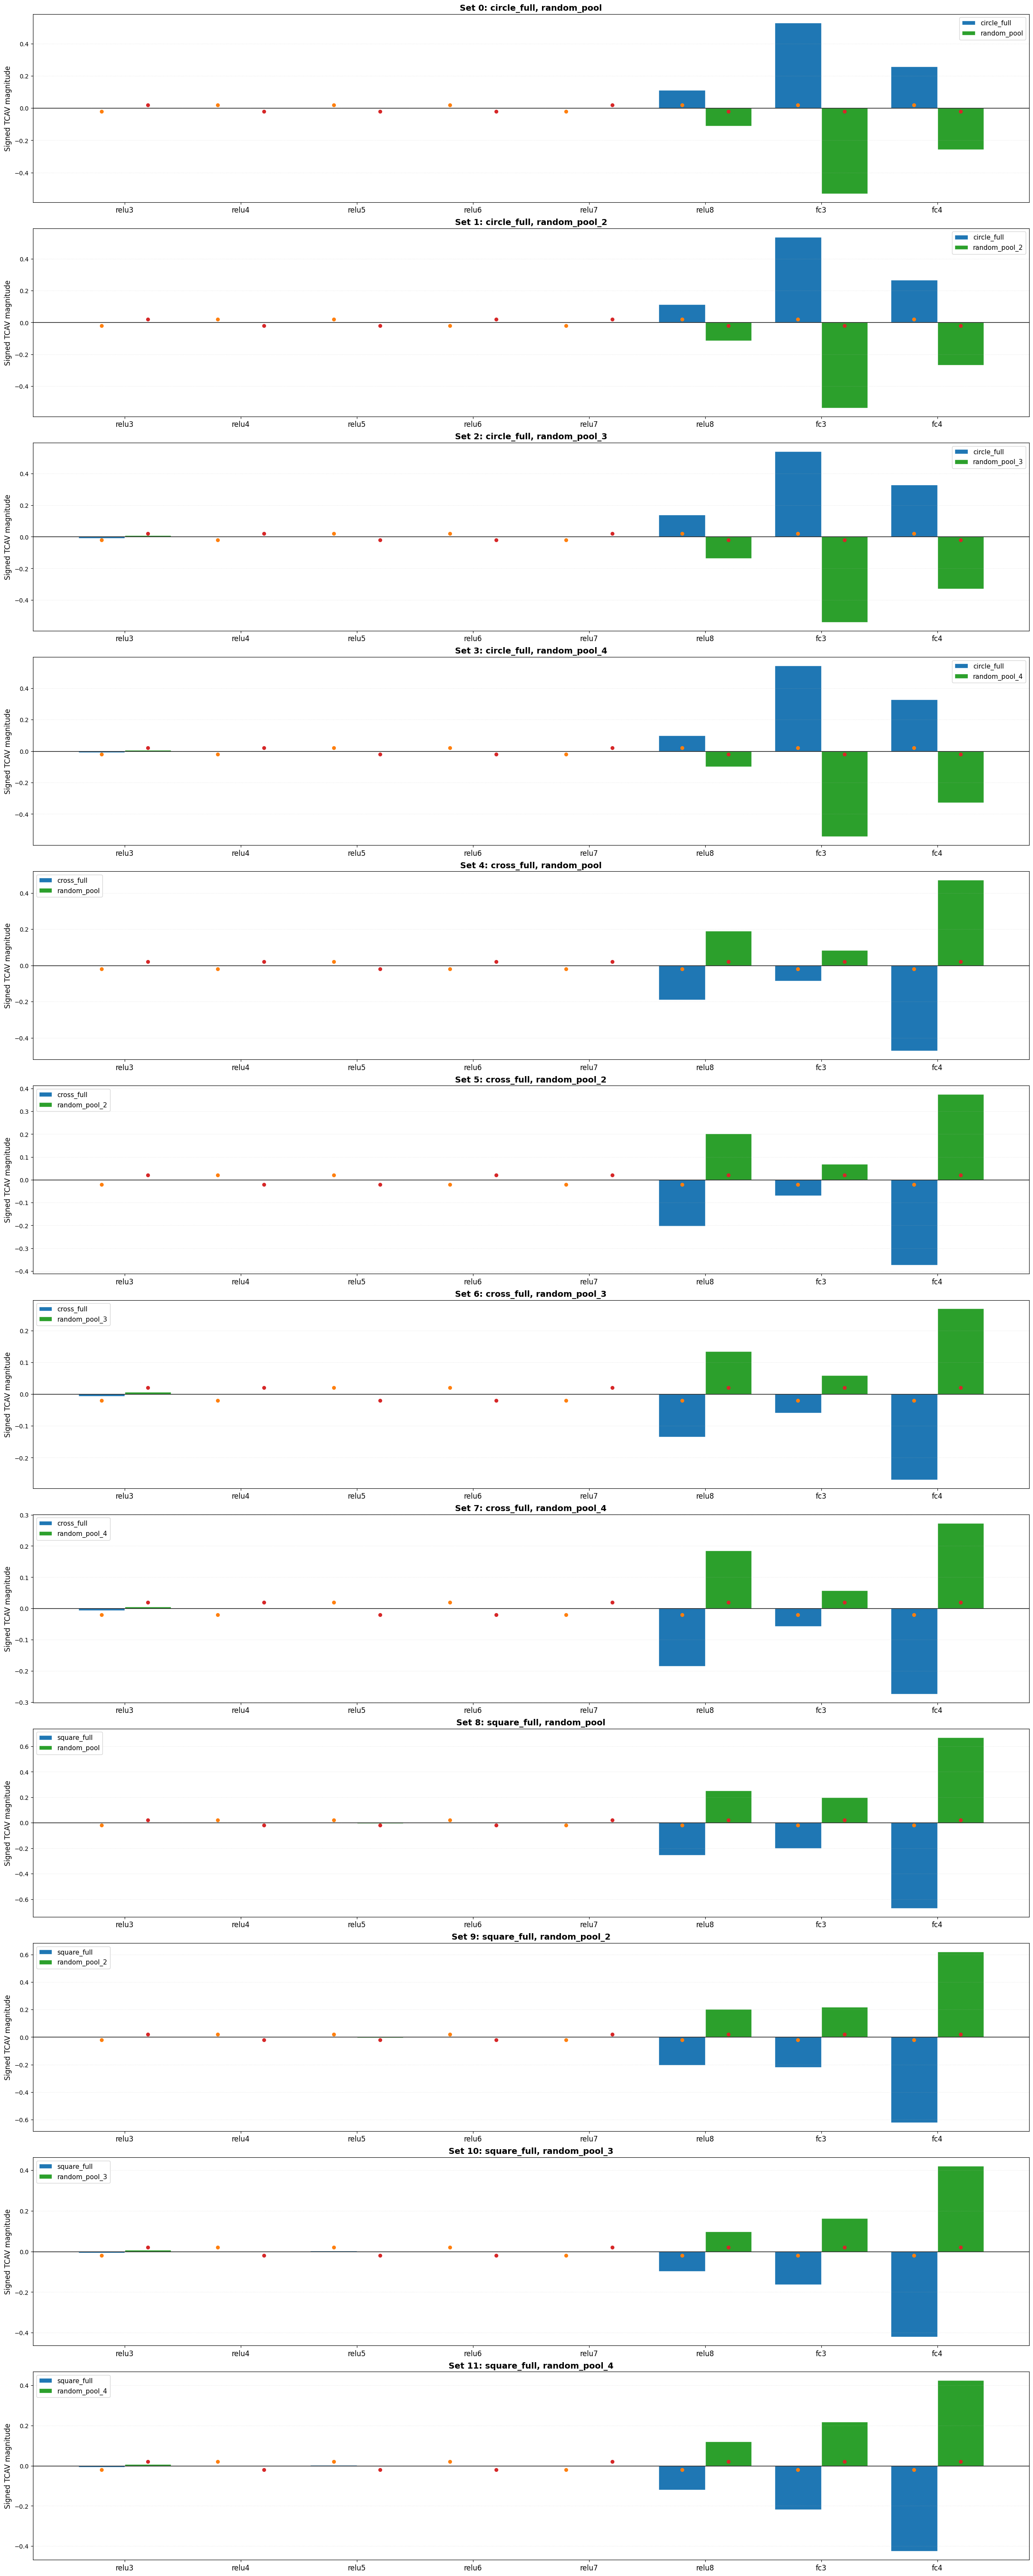

In [26]:
plot_tcav_directional(ALL_SETS, results_empty, layer_names=LAYERS, show_sign_dots=True)

In [16]:

val_dir = "data/aixi_shape/val"
val_paths = sorted(glob.glob(os.path.join(val_dir, "*.png")))
val_tensors = [transform(Image.open(p)).unsqueeze(0) for p in val_paths]  
val_inputs  = torch.cat(val_tensors, dim=0).to(DEVICE)              

print(f"Loaded {len(val_paths)} validation images.")

random_pools = [random_pool, random_pool_2, random_pool_3, random_pool_4]
sets_circle = [[circle_full,  rp] for rp in random_pools]
sets_cross  = [[cross_full,   rp] for rp in random_pools]
sets_square = [[square_full,  rp] for rp in random_pools]
all_sets = sets_circle + sets_cross + sets_square

tcav_global = TCAV(
    model=model,
    layers=LAYERS,
    layer_attr_method=LayerIntegratedGradients(model, None, multiply_by_inputs=False),
    attribute_to_layer_input=True,      # pre-ReLU
    model_id="global_tcav_full_concepts",
    save_path="./cav"
)
tcav_global.compute_cavs(all_sets, force_train=True)

Loaded 2000 validation images.


/opt/miniconda3/lib/python3.12/site-packages/captum/_utils/models/linear_model/train.py:409: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:257.)
  bias_values = torch.FloatTensor([sklearn_model.intercept_]).to(  # type: ignore


defaultdict(<function captum.concept._core.tcav.TCAV.__init__.<locals>.<lambda>()>,
            {'0-16': defaultdict(None,
                         {'relu3': <captum.concept._core.cav.CAV at 0x332ad4200>,
                          'relu4': <captum.concept._core.cav.CAV at 0x3c22d0ef0>,
                          'relu5': <captum.concept._core.cav.CAV at 0x43c5716a0>,
                          'relu6': <captum.concept._core.cav.CAV at 0x33b937f50>,
                          'relu7': <captum.concept._core.cav.CAV at 0x310358650>,
                          'relu8': <captum.concept._core.cav.CAV at 0x332b7fef0>,
                          'fc3': <captum.concept._core.cav.CAV at 0x310306960>,
                          'fc4': <captum.concept._core.cav.CAV at 0x332b7fdd0>}),
             '0-17': defaultdict(None,
                         {'relu3': <captum.concept._core.cav.CAV at 0x3c2393a70>,
                          'relu4': <captum.concept._core.cav.CAV at 0x332b7e180>,
                    

In [17]:
def flip_only_first_concept(tcav_scores, experimental_sets, anchor_layer="fc4"):
    """
    Flip concept (index 0) per set so its anchor layer magnitude is non-negative.
    Keeps random entry untouched. Works for local or global.
    """
    fixed = deepcopy(tcav_scores)
    for concepts in experimental_sets:
        ck = concepts_to_str(concepts)
        anchor = anchor_layer if anchor_layer in fixed[ck] else list(fixed[ck].keys())[-1]
        m0 = float(fixed[ck][anchor]['magnitude'][0])
        if m0 < 0:
            for ly in fixed[ck]:
                fixed[ck][ly]['magnitude'][0] = -fixed[ck][ly]['magnitude'][0]
                if 'sign_count' in fixed[ck][ly]:
                    sc = float(fixed[ck][ly]['sign_count'][0])
                    
    return fixed

def aggregate_across_pools(tcav_scores, experimental_sets, layers, idx=0):
    """
    For sets like [[concept, random_k], ...], return per-layer lists of:
      - sign_count values (one per pool)  -> fraction in [0,1]
      - magnitude values (one per pool)
    """
    sc, mag = {ly: [] for ly in layers}, {ly: [] for ly in layers}
    for concepts in experimental_sets:
        ck = concepts_to_str(concepts)
        for ly in layers:
            sc[ly].append(float(tcav_scores[ck][ly]['sign_count'][idx]))
            mag[ly].append(float(tcav_scores[ck][ly]['magnitude'][idx]))
    return sc, mag

def summarize_global(sc_dict):
    """
    Print mean ± std and a 1-sample t-test vs 0.5 for sign_count (standard TCAV null).
    """
    out = {}
    for ly, vals in sc_dict.items():
        vals = np.asarray(vals)
        mu, sd = float(vals.mean()), float(vals.std(ddof=1)) if len(vals) > 1 else 0.0
        t, p = (np.nan, np.nan) if len(vals) < 2 else ttest_1samp(vals, popmean=0.5)
        out[ly] = (mu, sd, float(p) if not np.isnan(p) else np.nan)
    return out

def print_summary(name, summary, label="sign_count"):
    print(f"\n=== Global TCAV ({label}) — {name} ===")
    for ly, (mu, sd, p) in summary.items():
        star = " *" if (not np.isnan(p) and p < 0.05) else ""
        print(f"{ly:>5s}: {mu:6.3f} ± {sd:6.3f}   (p={p:.3g}){star}")



In [18]:
common_kwargs = dict(target=0, n_steps=16, internal_batch_size=16)

raw_circle = tcav_global.interpret(inputs=val_inputs, experimental_sets=sets_circle, **common_kwargs)
raw_cross  = tcav_global.interpret(inputs=val_inputs, experimental_sets=sets_cross,  **common_kwargs)
raw_square = tcav_global.interpret(inputs=val_inputs, experimental_sets=sets_square, **common_kwargs)


circle = flip_only_first_concept(raw_circle, sets_circle, anchor_layer="fc4")
cross  = flip_only_first_concept(raw_cross,  sets_cross,  anchor_layer="fc4")
square = flip_only_first_concept(raw_square, sets_square, anchor_layer="fc4")


sc_circ, mag_circ = aggregate_across_pools(circle, sets_circle, LAYERS, idx=0)
sc_cross, mag_cross = aggregate_across_pools(cross, sets_cross, LAYERS, idx=0)
sc_sq, mag_sq = aggregate_across_pools(square, sets_square, LAYERS, idx=0)


sum_sc_circ  = summarize_global(sc_circ)
sum_sc_cross = summarize_global(sc_cross)
sum_sc_sq    = summarize_global(sc_sq)

print_summary("circle_full",  sum_sc_circ,  label="sign_count (fraction ↑ along CAV)")
print_summary("cross_full",   sum_sc_cross, label="sign_count (fraction ↑ along CAV)")
print_summary("square_full",  sum_sc_sq,    label="sign_count (fraction ↑ along CAV)")


def plot_sc_means(sc_dicts, labels, layers=LAYERS):
    import numpy as np, matplotlib.pyplot as plt
    x = np.arange(len(layers))
    w = 0.25
    fig, ax = plt.subplots(figsize=(8, 4))
    for i, scd in enumerate(sc_dicts):
        means = [np.mean(scd[ly]) for ly in layers]
        ax.bar(x + (i - (len(sc_dicts)-1)/2)*w, means, width=w, label=labels[i])
    ax.axhline(0.5, color='k', ls='--', lw=1) 
    ax.set_xticks(x); ax.set_xticklabels(layers)
    ax.set_ylim(0,1)
    ax.set_ylabel("TCAV sign_count (fraction ↑)")
    ax.legend(); ax.set_title("Global TCAV (val set)")
    plt.tight_layout(); plt.show()

plot_sc_means([sc_circ, sc_cross, sc_sq], ["circle", "cross", "square"], layers=LAYERS)

/opt/miniconda3/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 2000 equal to the number of examples.
  warnings.warn(


NameError: name 'ttest_1samp' is not defined

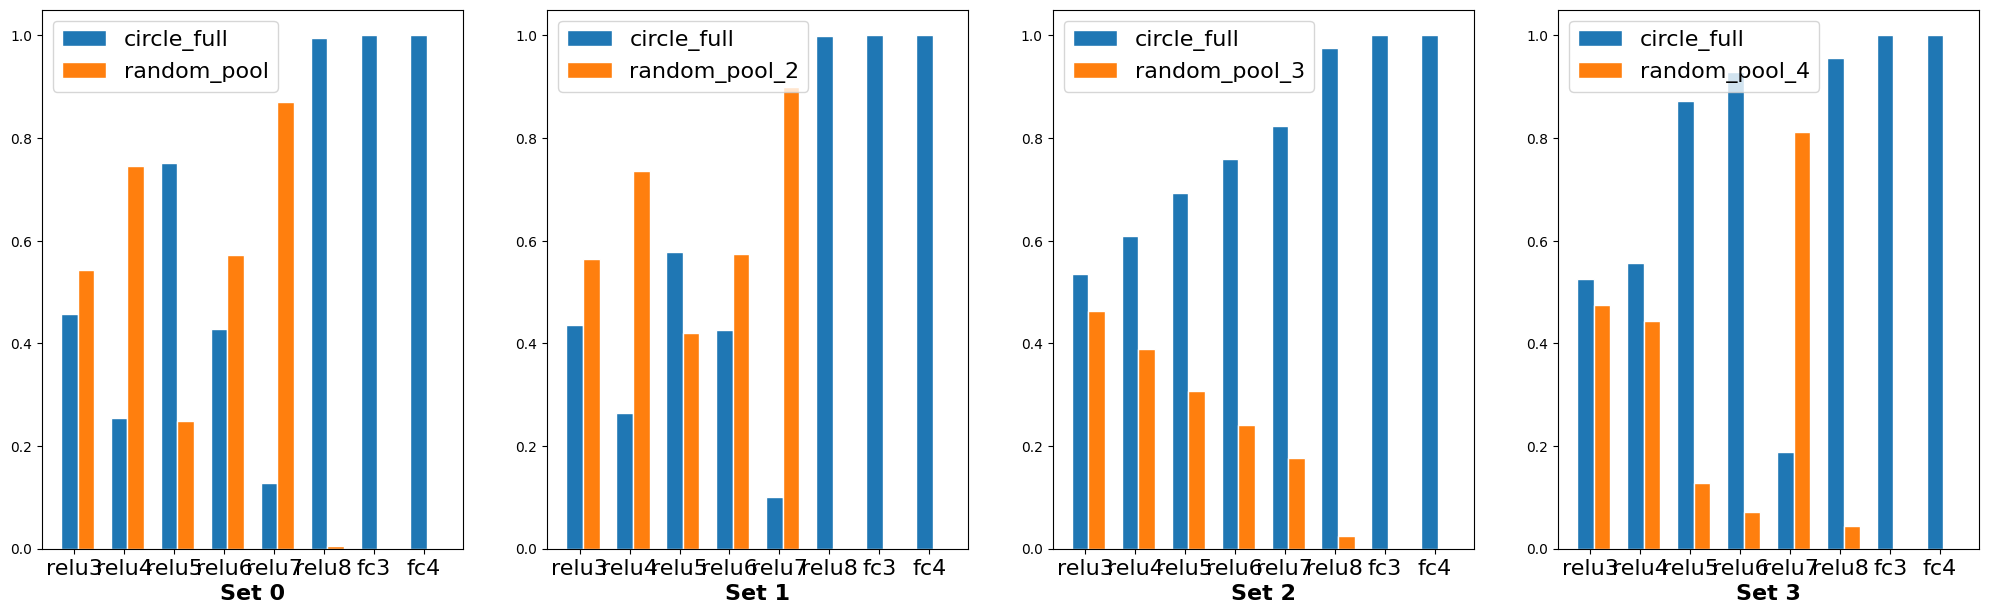

In [19]:
plot_tcav_scores(tcav_scores=raw_circle, experimental_sets=sets_circle, layers=LAYERS)

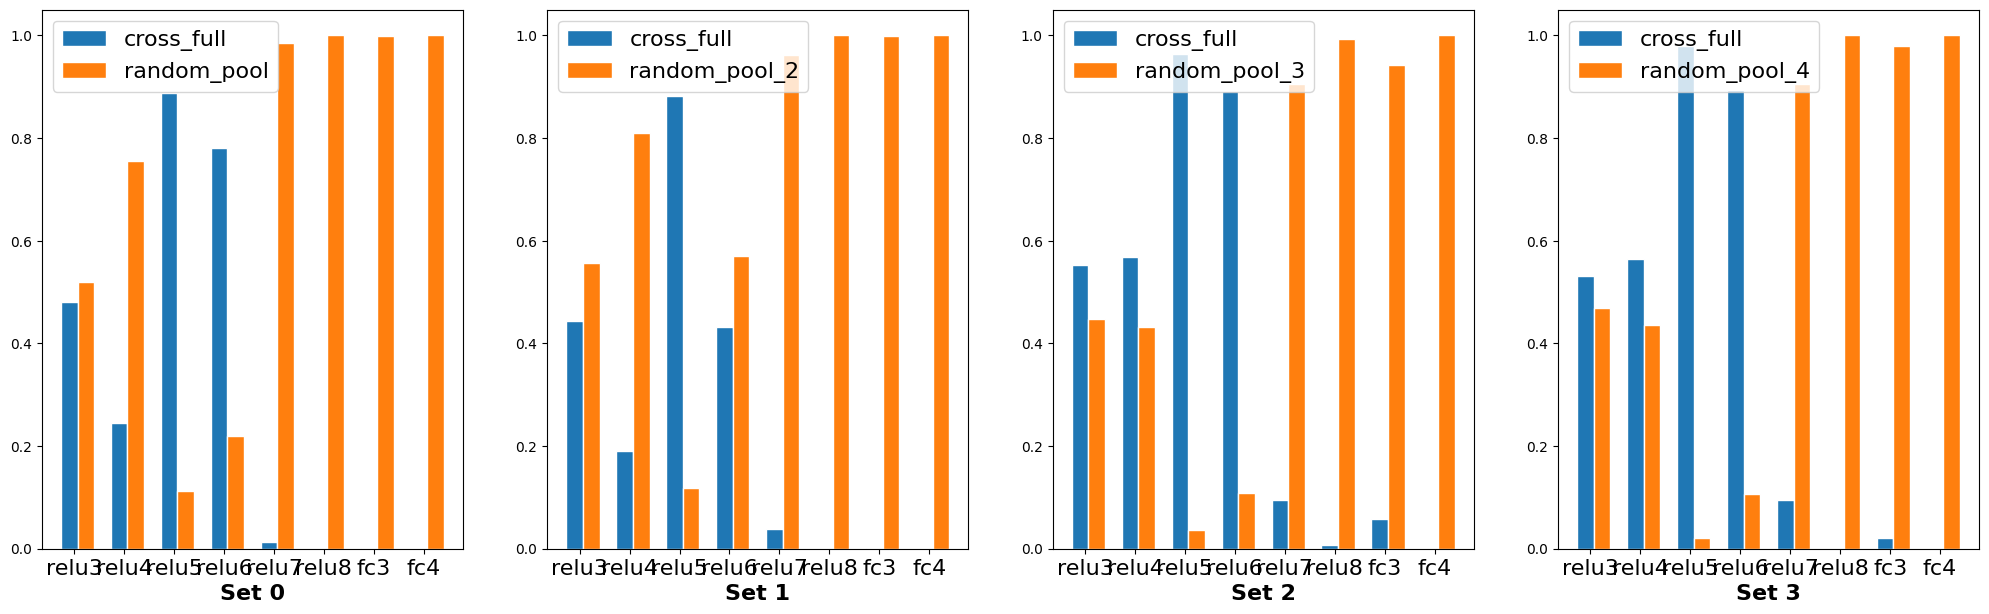

In [20]:
plot_tcav_scores(tcav_scores=raw_cross, experimental_sets=sets_cross, layers=LAYERS)

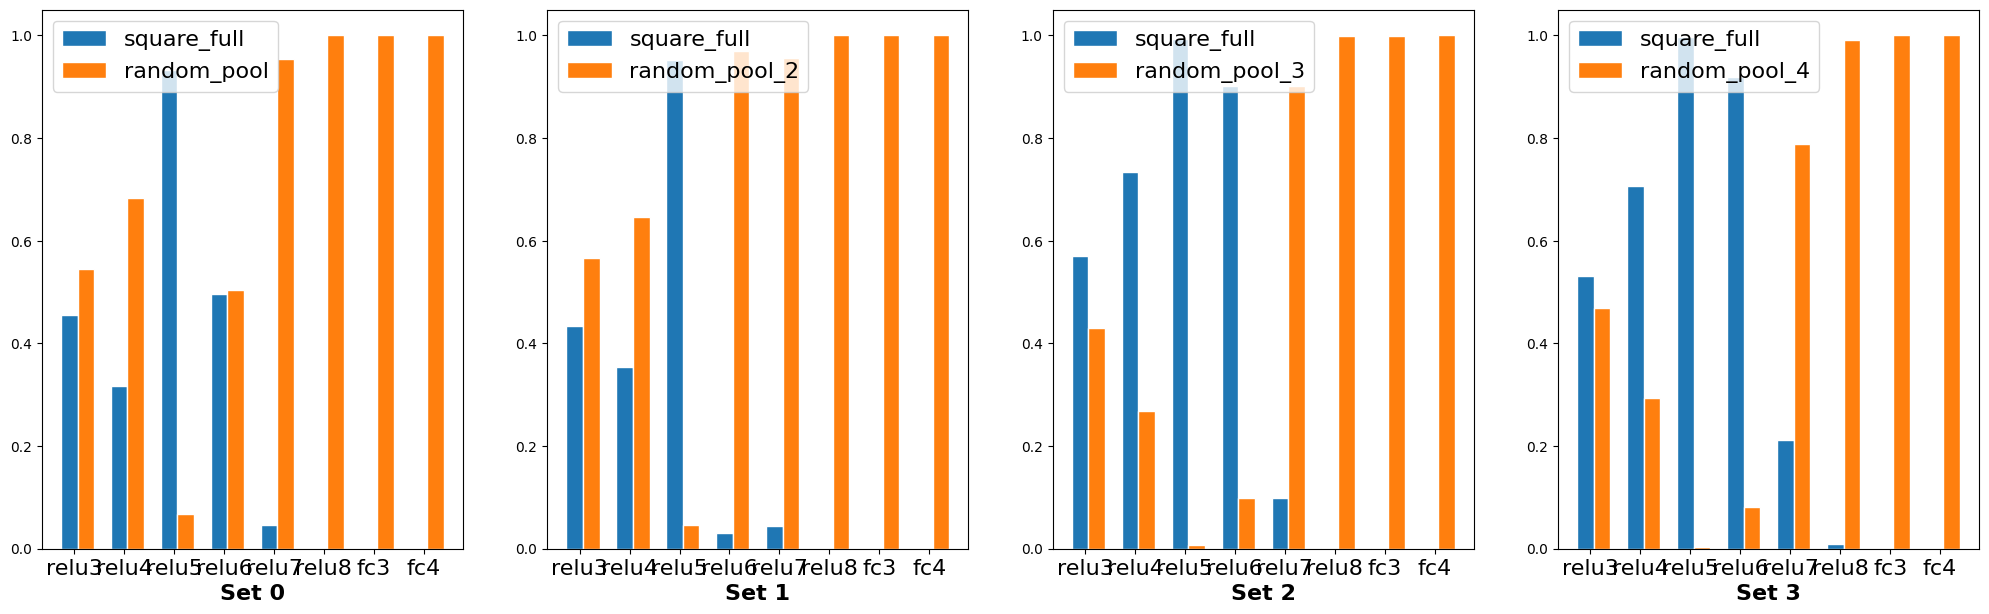

In [22]:
plot_tcav_scores(tcav_scores=raw_square, experimental_sets=sets_square, layers=LAYERS)

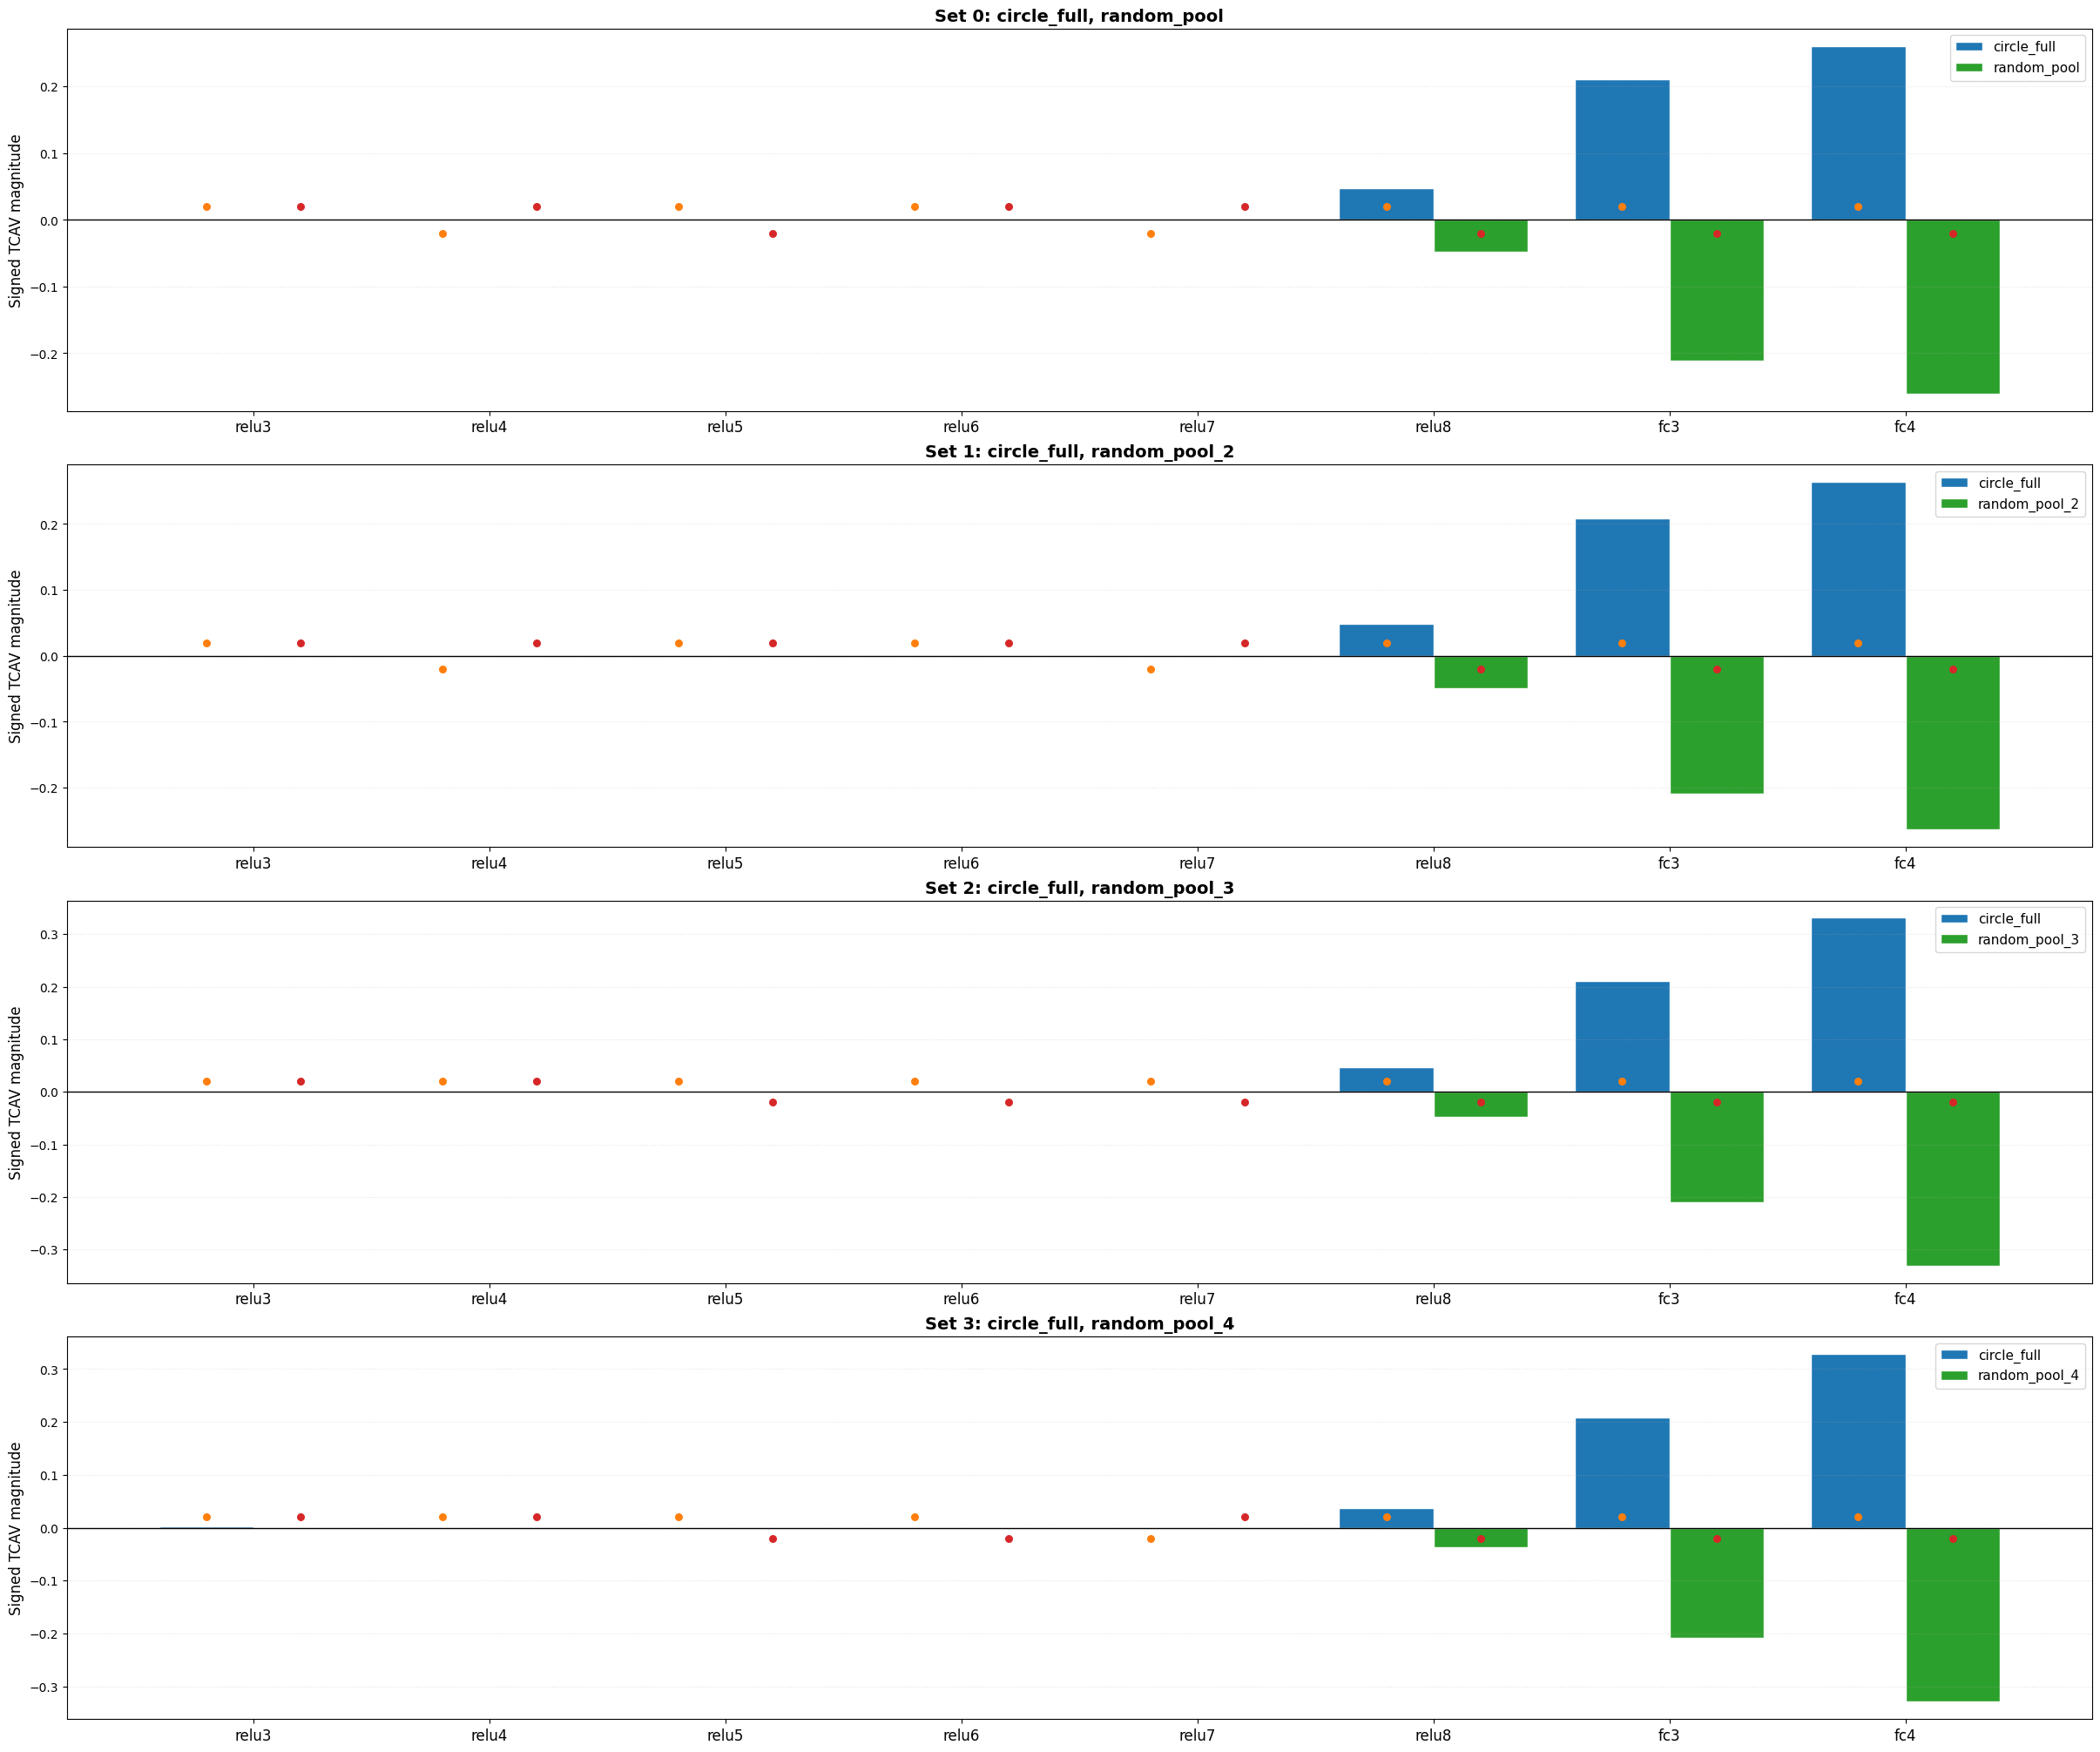

In [23]:
plot_tcav_directional(tcav_scores=raw_circle, experimental_sets=sets_circle, layer_names=LAYERS, show_sign_dots=True)

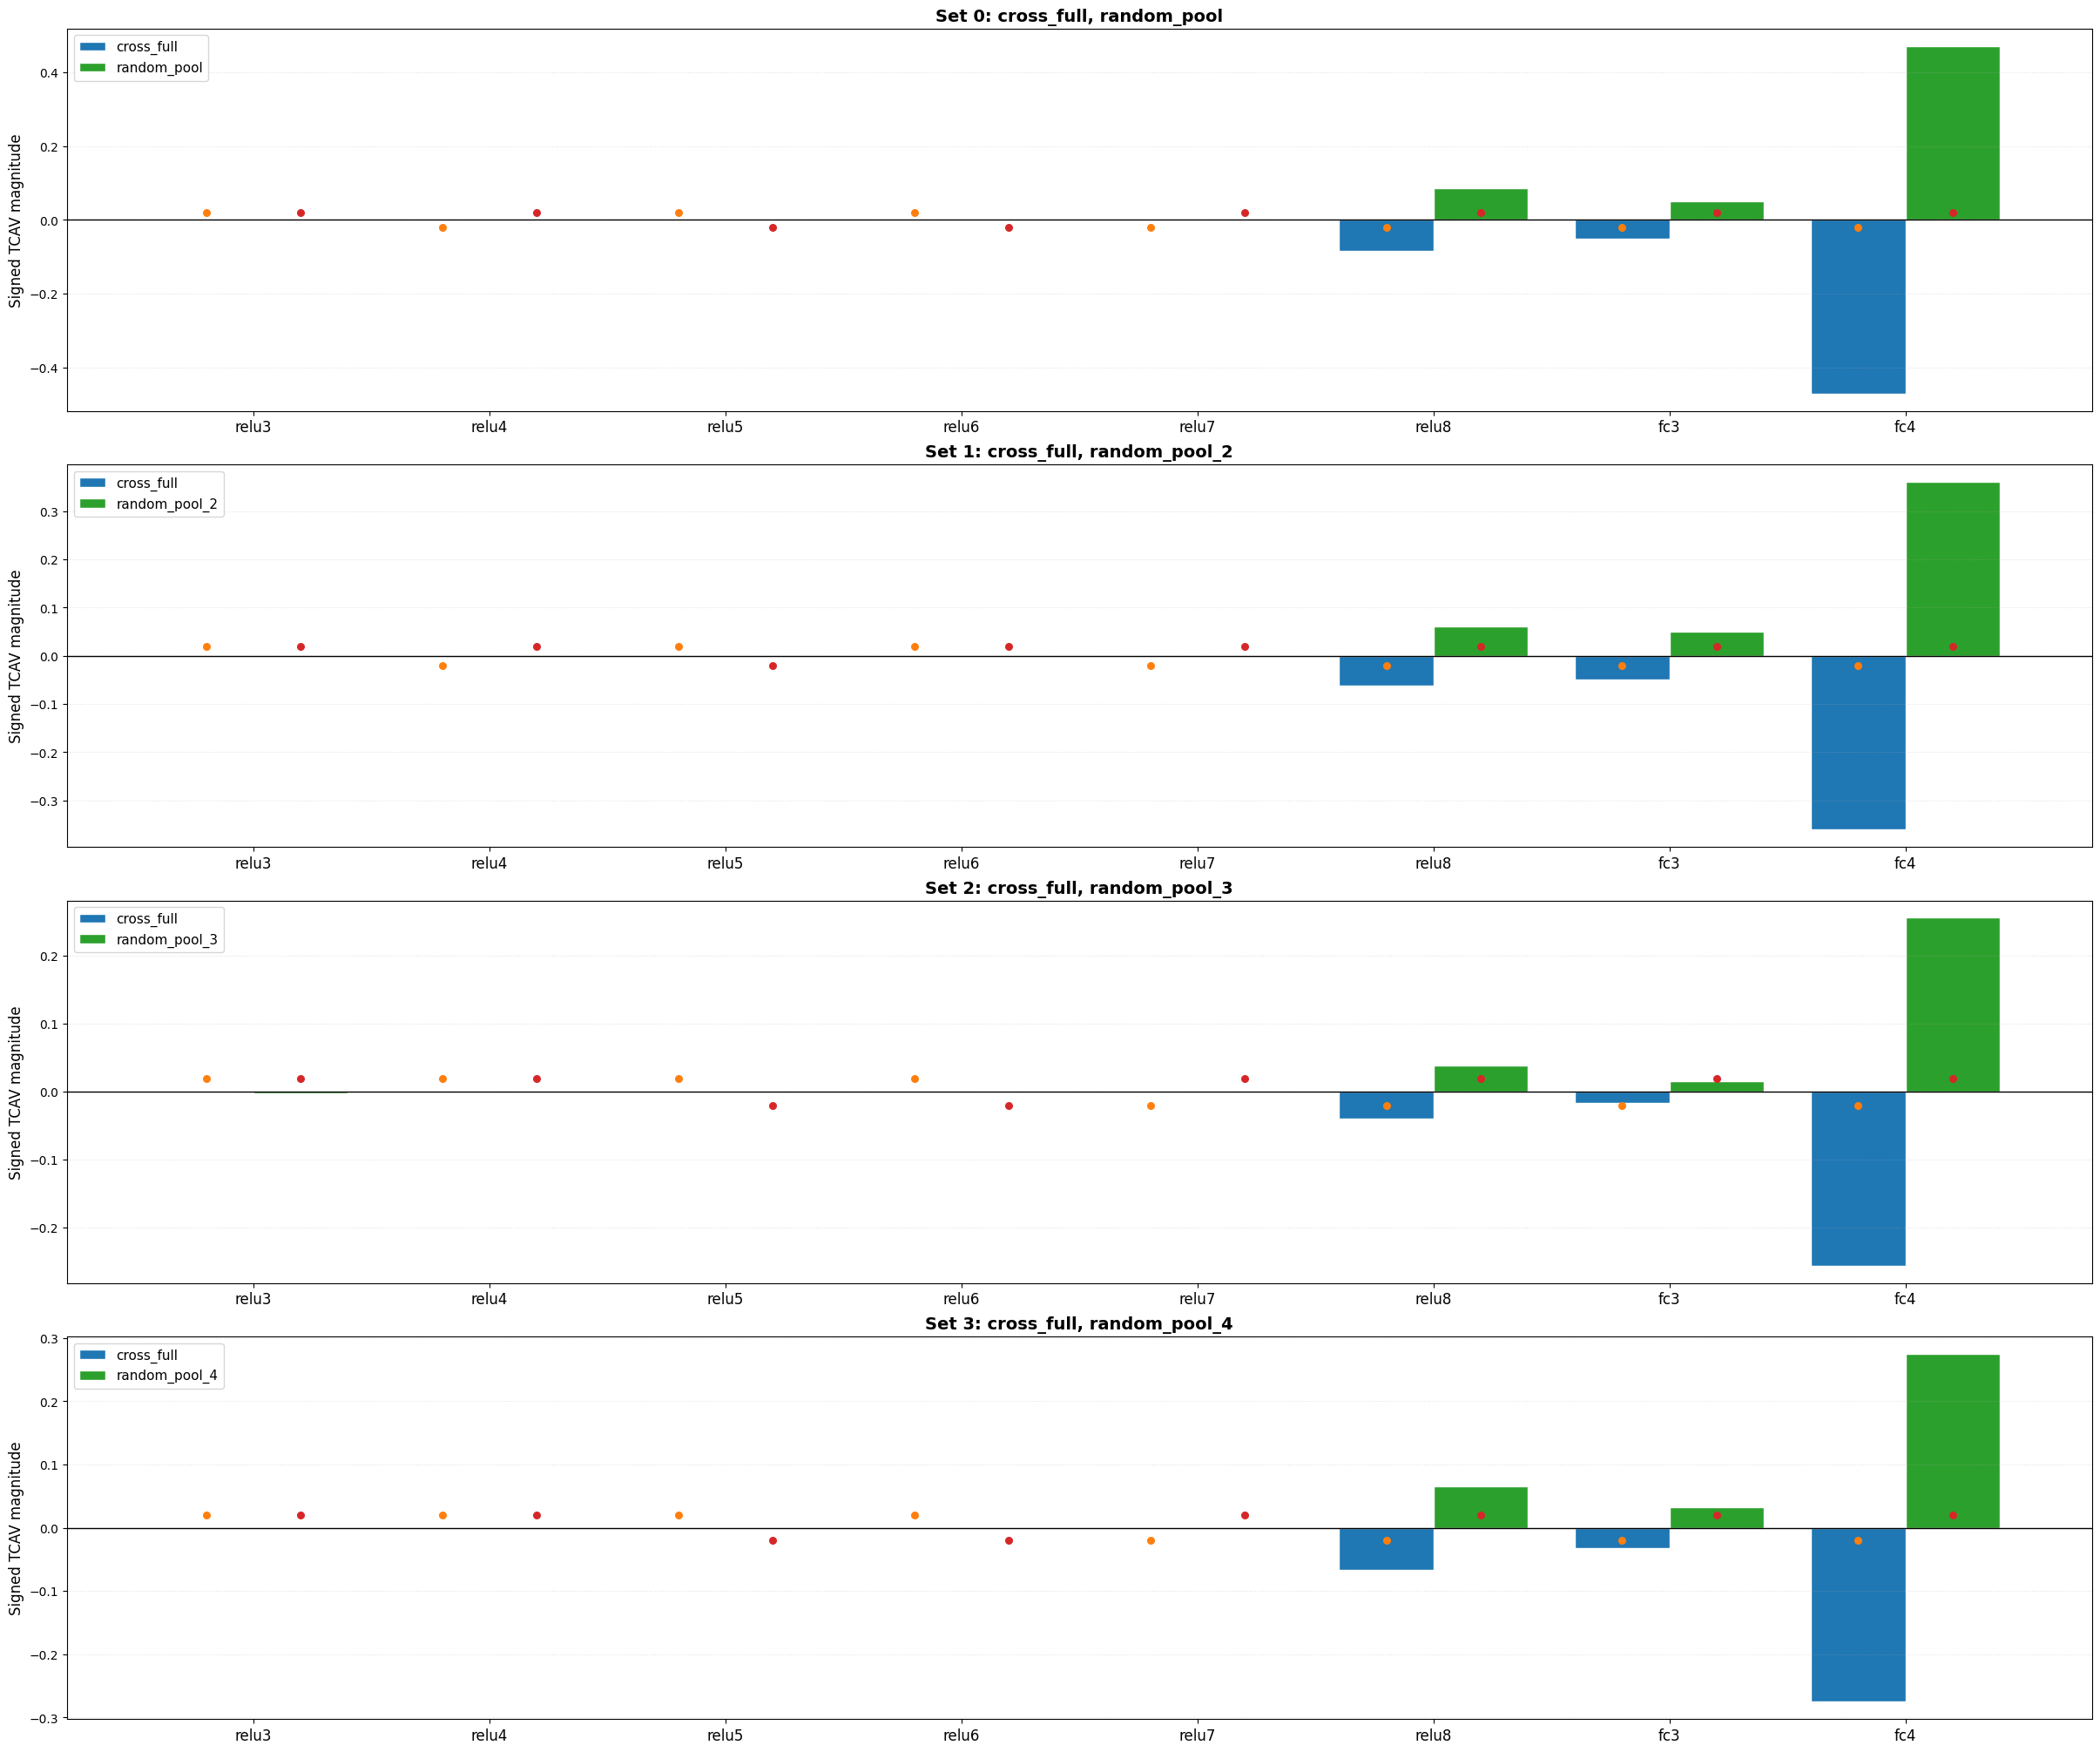

In [24]:
plot_tcav_directional(tcav_scores=raw_cross, experimental_sets=sets_cross, layer_names=LAYERS, show_sign_dots=True)

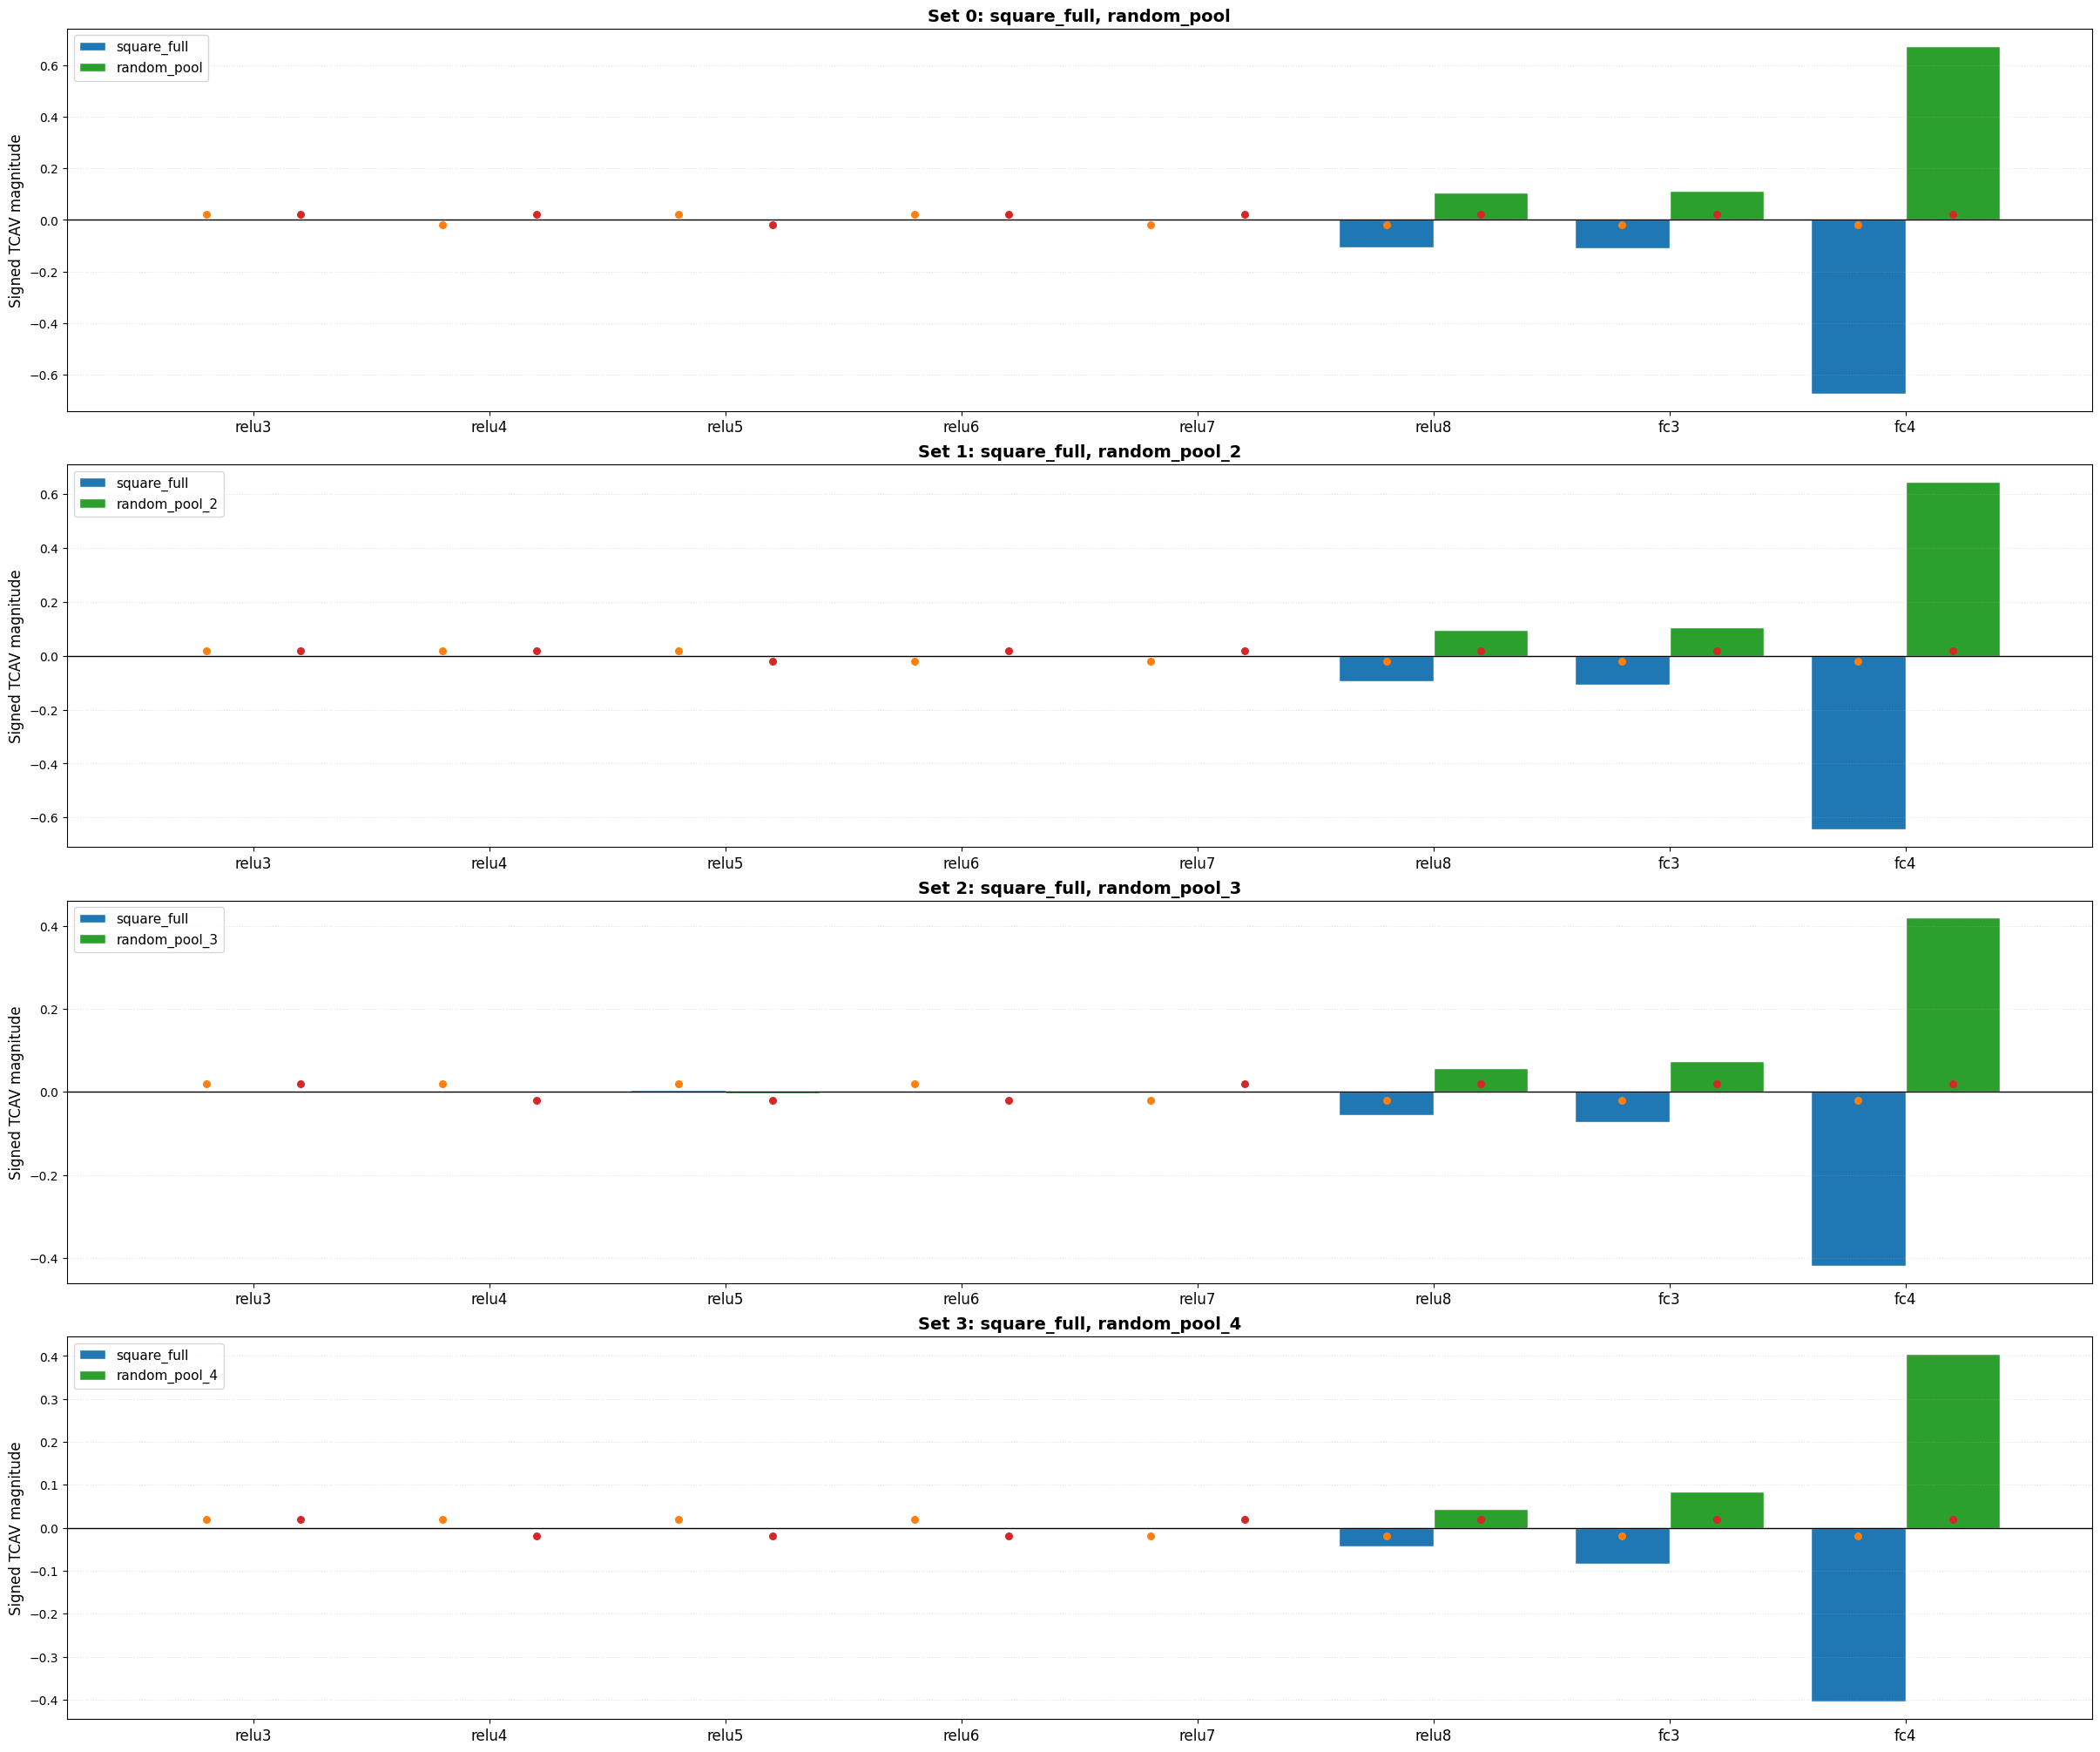

In [25]:
plot_tcav_directional(tcav_scores=raw_square, experimental_sets=sets_square, layer_names=LAYERS, show_sign_dots=True)